In [ ]:
import torch
from torch import nn # contains all the neccessary blocks to create a neural net in pytorch
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

In [ ]:
#Preparing and loading the data

weigth = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
x = torch.arange(start,end,step).unsqueeze(dim=1)
y = weigth * x + bias

In [ ]:
x[:10], y[:10], len(x), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [ ]:
#Create a train, test, split

train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]
len(x_test), len(y_train)

(10, 40)

In [ ]:
def plot_predictions(train_data = x_train, train_label = y_train, test_data = x_test, test_label = y_test, predictions = None):

  plt.figure(figsize=(10, 7))
  plt.scatter(train_data, train_label, c="b", s=4, label="Training Data")
  plt.scatter(test_data, test_label, c="g", s=4, label="Testing Data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Prediction Data")
  plt.legend(prop={"size": 14})

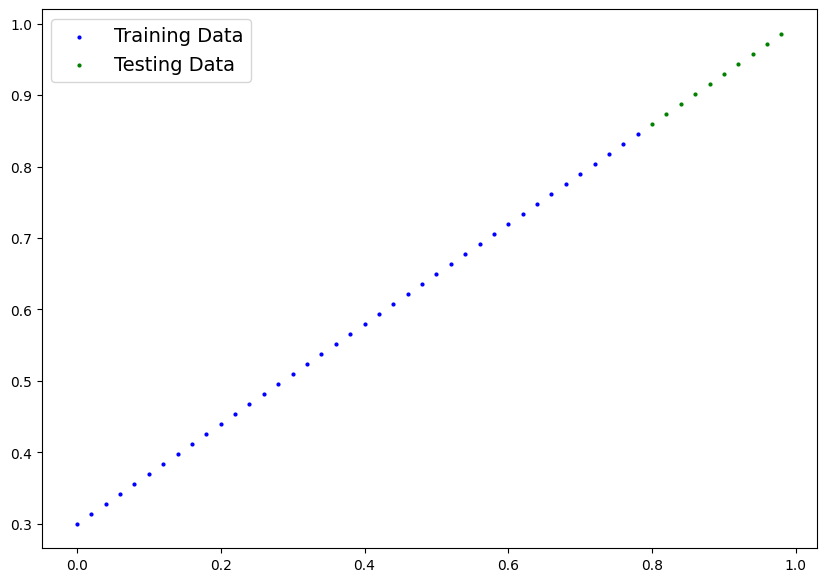

In [ ]:
plot_predictions()

# Building a model


In [ ]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  def forward(self, x: torch.tensor) -> torch.tensor:
    return self.weights * x + self.bias

In [ ]:
torch.manual_seed(42)

model_0 = LinearRegression()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
weigth, bias

(0.7, 0.3)

In [ ]:
with torch.inference_mode():
  y_preds = model_0(x_test)

y_test, y_preds

(tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]),
 tensor([[0.3982],
         [0.4049],
         [0.4116],
         [0.4184],
         [0.4251],
         [0.4318],
         [0.4386],
         [0.4453],
         [0.4520],
         [0.4588]]))

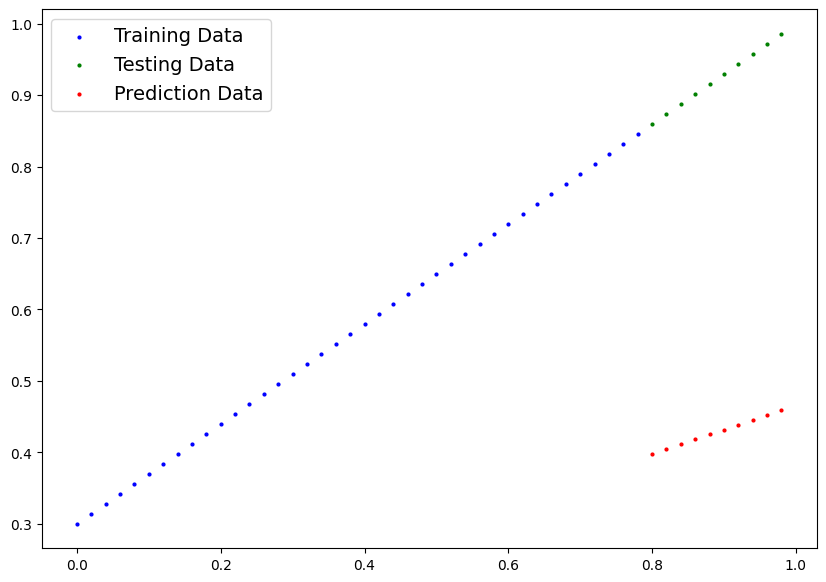

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
#Loss function
loss_fn = nn.L1Loss()

#Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [ ]:
loss_fn, optimizer

(L1Loss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [ ]:
import torch # Re-import torch to ensure manual_seed is a function
torch.manual_seed(42)
epochs = 100 # Total no of times data goes through the training

for epoch in range(epochs):

  model_0.train() # Set the model for training mode

  y_pred = model_0(x_train) # Forward propagation

  loss = loss_fn(y_pred, y_train) # Loss Function
  print(f"Loss: {loss}")

  optimizer.zero_grad() # Optimizer zero grad

  loss.backward() # Backward propagation

  optimizer.step() # Optimizer step

  model_0.eval()

Loss: 0.31288138031959534
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Loss: 0.08227583020925522
Loss: 0.07638873159885406
Loss: 0.07160007208585739
Loss: 0.06747635453939438
Loss: 0.06395438313484192
Loss: 0.06097004935145378
Loss: 0.05845819041132927
Loss: 0.05635259300470352
Loss: 0.0545857772231102
Loss: 0.053148526698350906
Loss: 0.05181945487856865
Loss: 0.05069301277399063
Loss: 0.0498228520154953
Loss: 0.04895269125699997
Loss: 0.04819351062178612
Loss: 0.047531817108392715
Loss: 0.04692792519927025
Loss: 0.046423316001

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [ ]:
weigth, bias

(0.7, 0.3)

In [ ]:
with torch.inference_mode():
  y_pred_new = model_0(x_test)

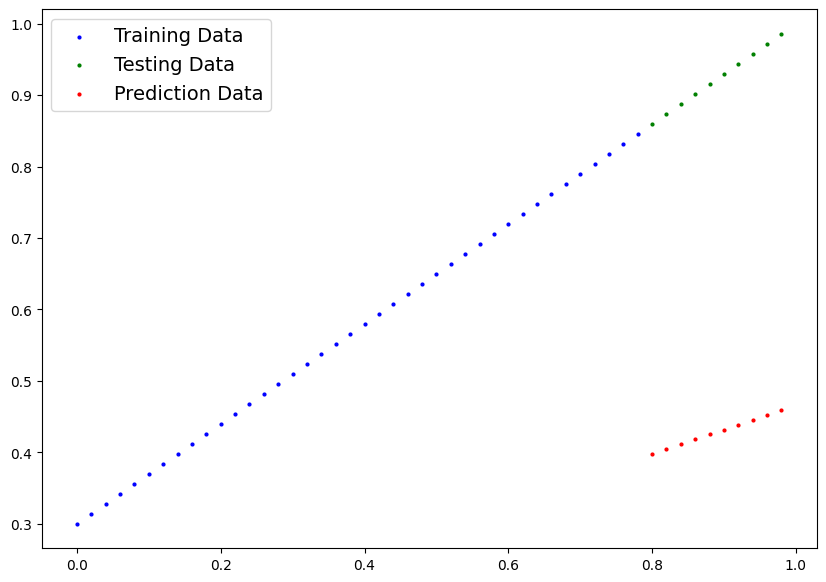

In [ ]:
plot_predictions(predictions=y_preds)

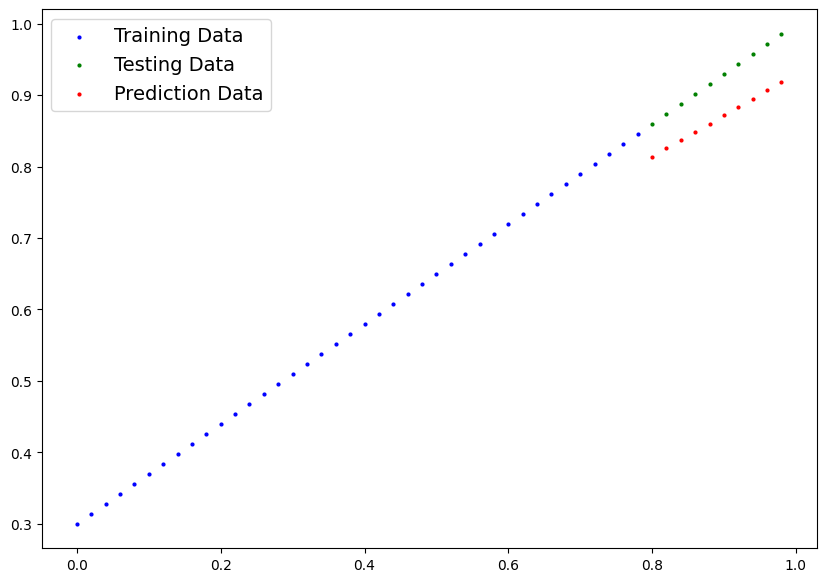

In [ ]:
plot_predictions(predictions=y_pred_new)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [ ]:
# Saving a model in Pytorch

from pathlib import Path

# 1. create a model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to models/01_pytorch.pth


In [ ]:
!ls

models	sample_data


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 1917 Feb 22 13:14 01_pytorch.pth


In [ ]:
# Loading a PyTorch model

load_model_0 = LinearRegression() # new instance of the model class
load_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH)) # load the state_dict of the model
load_model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [ ]:
# Make some predictions with the loaded model

load_model_0.eval()
with torch.inference_mode():
  load_model_preds = load_model_0(x_test)

load_model_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [ ]:
y_pred_new == load_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

### Putting all things together

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

torch.__version__

'2.10.0+cpu'

In [ ]:
# Device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device using: {device}")

Device using: cpu


### Data

In [ ]:
# Create some data using Linear Regression formula y = weight * x + bias

weight = 0.7
bias = 0.3

x = torch.arange(start=0, end=1, step=0.02).unsqueeze(dim=1)
y = weight * x + bias
x[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# split data

train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

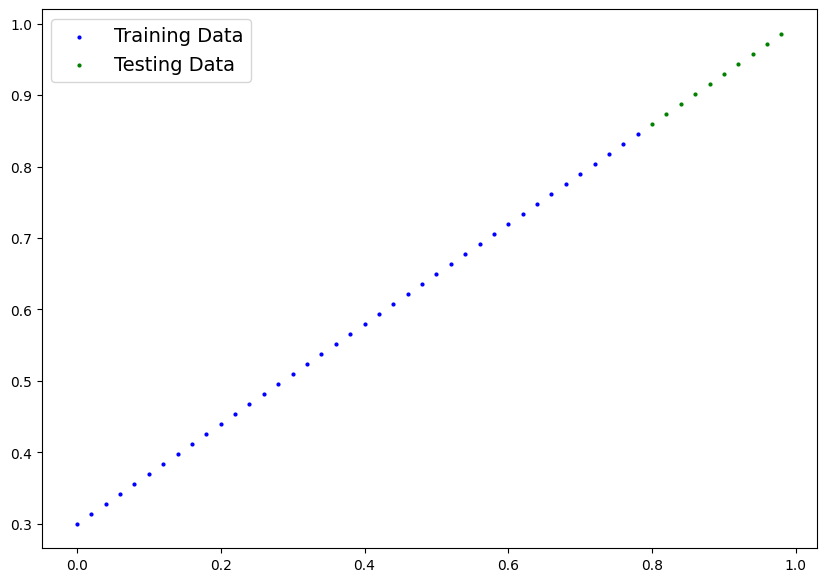

In [ ]:
# plot the data
plot_predictions(x_train, y_train, x_test, y_test, predictions=None)

## Building a PyTorch Linear Model

In [ ]:
# Create a linear model by using subclassing nn.Module

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear for creating the model parameters
    self.linear_layer = nn.Linear(in_features=1, out_features=1)

  def forward(self, x: torch.tensor) -> torch.tensor:
    return self.linear_layer(x)

torch.manual_seed(42)

model_1 = LinearRegressionModel()
model_1, model_1.state_dict()

(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
#Loss funciton
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

loss_fn, optimizer

(L1Loss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [ ]:
torch.manual_seed(42)
epochs = 100
for epoch in range(epochs+1):
  model_1.train() # Set the model to train ready

  y_pred = model_1(x_train) # Forward Passing

  loss = loss_fn(y_pred, y_train) # Implement the loss function (MAE in this case)

  optimizer.zero_grad() # Flush the previous gradients

  loss.backward() # Backward propagation for improving the weights

  optimizer.step() # Recalulating the weights

  model_1.eval() # stop training and set the model for evaluation

  with torch.inference_mode():
    test_pred = model_1(x_test)

    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779866218567 | Test Loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399680495262146 | Test Loss: 0.4392663538455963
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954827964305878 | Test Loss: 0.16984674334526062
Epoch: 40 | Loss: 0.09433844685554504 | Test Loss: 0.03513689711689949
Epoch: 50 | Loss: 0.023886386305093765 | Test Loss: 0.04784906655550003
Epoch: 60 | Loss: 0.0199567973613739 | Test Loss: 0.04580312222242355
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss: 0.0375305712223053
Epoch: 80 | Loss: 0.013089170679450035 | Test Loss: 0.029944902285933495
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215679459273815 | Test Loss: 0.014086711220443249


In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6707]])),
             ('linear_layer.bias', tensor([0.3120]))])

In [ ]:
weight, bias

(0.7, 0.3)

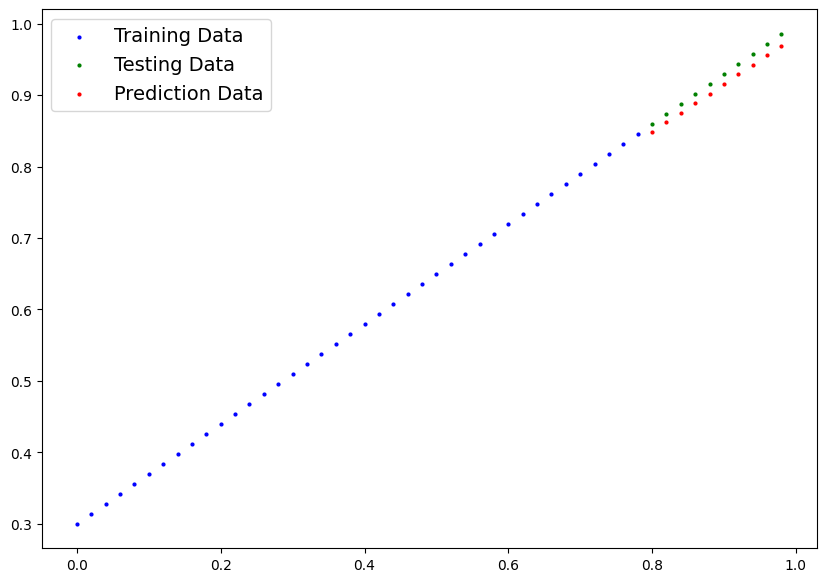

In [ ]:
plot_predictions(predictions=test_pred)

In [ ]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "02_pytorch_linear_model.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

Saving model to models/02_pytorch_linear_model.pt


In [ ]:
# Load the model from the disk

model = LinearRegressionModel()
model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6707]])),
             ('linear_layer.bias', tensor([0.3120]))])

In [ ]:
with torch.inference_mode():
  y_preds_load = model(x_test)

y_preds_load

tensor([[0.8486],
        [0.8620],
        [0.8754],
        [0.8888],
        [0.9022],
        [0.9156],
        [0.9290],
        [0.9424],
        [0.9559],
        [0.9693]])

In [ ]:
y_preds == y_preds_load

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

### MultiVarient LinearRegression

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

torch.__version__

'2.10.0+cpu'

In [ ]:
weight_1 = 3
weight_2 = 2
bias = 1

x1 = torch.arange(start=0, end=1, step=0.02).unsqueeze(dim=1)
x2 = torch.arange(start=0, end=1, step=0.02).unsqueeze(dim=1)

x = torch.cat([x1, x2], dim=-1)
y = 3 * x1 + 2 * x2 + 1

x.shape, len(x), len(y)

(torch.Size([50, 2]), 50, 50)

In [ ]:
# spliting the data
train_split = int(0.8 * len(x))

x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

len(x_train), len(x_test), len(y_train), len(y_test)

(40, 10, 40, 10)

In [ ]:
def plot_predictions(x_train, y_train, x_test, y_test, predictions=None, feature_idx=0):
    plt.figure(figsize=(10, 6))

    x_train = x_train[:, feature_idx].detach().cpu().numpy()
    y_train = y_train.squeeze().detach().cpu().numpy()
    x_test = x_test[:, feature_idx].detach().cpu().numpy()
    y_test = y_test.squeeze().detach().cpu().numpy()

    plt.scatter(x_train, y_train, label="Train", s=20)
    plt.scatter(x_test, y_test, label="Test", s=20)

    if predictions is not None:
        preds = predictions.squeeze().detach().cpu().numpy()
        plt.scatter(x_test, preds, label="Predictions", s=20)

    plt.legend()
    plt.grid()
    plt.show()

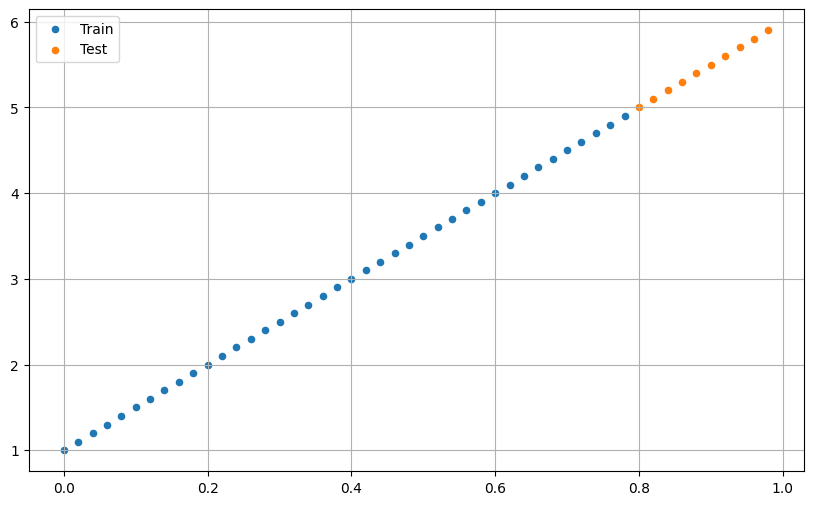

In [ ]:
plot_predictions(x_train, y_train, x_test, y_test)

In [ ]:
class LinearRegressionMultiVarient(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layers = nn.Linear(in_features=2, out_features=1)

  def forward(self, x: torch.tensor) -> torch.tensor:
    return self.linear_layers(x)

In [ ]:
LinearRegressionMultiVarient()

LinearRegressionMultiVarient(
  (linear_layers): Linear(in_features=2, out_features=1, bias=True)
)

In [ ]:
torch.manual_seed(42)
model_2 = LinearRegressionMultiVarient()
model_2.state_dict()

OrderedDict([('linear_layers.weight', tensor([[0.5406, 0.5869]])),
             ('linear_layers.bias', tensor([-0.1657]))])

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [ ]:
loss_fn, optimizer

(L1Loss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [ ]:
torch.manual_seed(42)
epochs = 600

for epoch in range(epochs):
  model_2.train()
  y_pred = model_2(x_train)
  loss_value = loss_fn(y_pred, y_train)
  optimizer.zero_grad()
  loss_value.backward()
  optimizer.step()

  model_2.eval()

  with torch.inference_mode():
    test_pred = model_2(x_test)
    test_loss_value = loss_fn(test_pred, y_test) # Corrected from 'loss' to 'loss_fn'

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss_value} | Test Loss: {test_loss_value}")

Epoch: 0 | Loss: 0.12351937592029572 | Test Loss: 0.27220290899276733
Epoch: 10 | Loss: 0.11758007854223251 | Test Loss: 0.25925111770629883
Epoch: 20 | Loss: 0.11163513362407684 | Test Loss: 0.24629946053028107
Epoch: 30 | Loss: 0.10569028556346893 | Test Loss: 0.23334750533103943
Epoch: 40 | Loss: 0.09975375980138779 | Test Loss: 0.21950426697731018
Epoch: 50 | Loss: 0.09381518512964249 | Test Loss: 0.20655246078968048
Epoch: 60 | Loss: 0.08787031471729279 | Test Loss: 0.19360069930553436
Epoch: 70 | Loss: 0.0819253921508789 | Test Loss: 0.18064895272254944
Epoch: 80 | Loss: 0.07598825544118881 | Test Loss: 0.16680555045604706
Epoch: 90 | Loss: 0.07005034387111664 | Test Loss: 0.15385356545448303
Epoch: 100 | Loss: 0.06410540640354156 | Test Loss: 0.14090204238891602
Epoch: 110 | Loss: 0.05816052109003067 | Test Loss: 0.1279502809047699
Epoch: 120 | Loss: 0.052222657948732376 | Test Loss: 0.11410665512084961
Epoch: 130 | Loss: 0.04628540948033333 | Test Loss: 0.10115523636341095
Epoc

In [ ]:
model_2.state_dict()

OrderedDict([('linear_layers.weight', tensor([[2.4725, 2.5188]])),
             ('linear_layers.bias', tensor([0.9996]))])

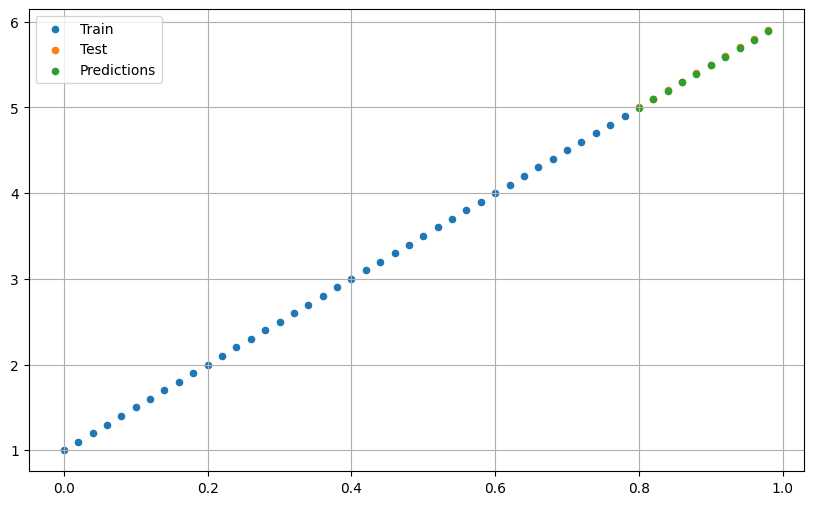

In [ ]:
plot_predictions(x_train, y_train, x_test, y_test, predictions=test_pred)

In [ ]:
from pathlib import Path

MODEL_NAME = "pytroch_multivarient_model.pth"
MODEL_PATH = Path("models")

MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

Saving model to models/pytroch_multivarient_model.pth


In [ ]:
load_model_2 = LinearRegressionMultiVarient()
load_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
load_model_2.state_dict()

OrderedDict([('linear_layers.weight', tensor([[2.4725, 2.5188]])),
             ('linear_layers.bias', tensor([0.9996]))])

In [ ]:
with torch.inference_mode():
  load_model_2_pred = model_2(x_test)

test_pred == load_model_2_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])